# **Texture-based Nearest Neighbors Image Retrieval (Pattern Matching)**

METODE

EKSTRAKSI FITUR

1.   Local Binary Pattern (LBP)
2.   Histogram of Oriented Gradients (HOG)

Perhitungan Jarak


1.   Jarak Euclidean
2.   Cosine similarity


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ekstraksi fitur dari dataset referensi...


/usr/local/lib/python3.10/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3


Menampilkan sampel citra referensi...


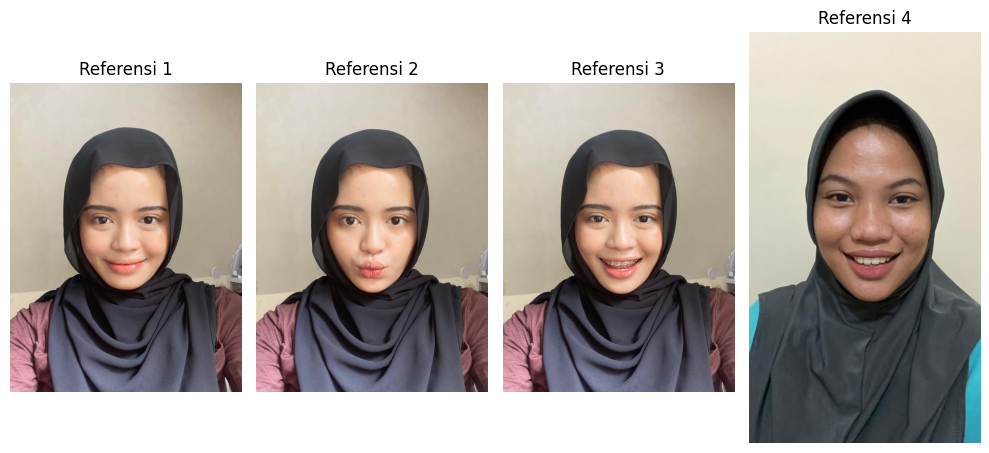


Ekstraksi fitur dari dataset uji...


/usr/local/lib/python3.10/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(



Menghitung jarak ke citra referensi...

Citra referensi terdekat (Jarak Euclidean):
Rank 1: Zahra (4).jpg, Jarak Euclidean: 11.824153350553724
Rank 2: Zahra (5).jpg, Jarak Euclidean: 11.863449314469277
Rank 3: Zahra (2).jpg, Jarak Euclidean: 11.90356073283893
Rank 4: Zahra (1).jpg, Jarak Euclidean: 12.002941464290004
Rank 5: Zahra (6).jpg, Jarak Euclidean: 12.003341704976163

Citra referensi terdekat (Cosine Similarity):
Rank 1: Zahra (4).jpg, Cosine Similarity: 0.31055994006083476
Rank 2: Zahra (5).jpg, Cosine Similarity: 0.31262757460902624
Rank 3: Zahra (2).jpg, Cosine Similarity: 0.3147452224806798
Rank 4: Zahra (1).jpg, Cosine Similarity: 0.32002365278512834
Rank 5: Zahra (6).jpg, Cosine Similarity: 0.3200444438478579

Menampilkan citra referensi terdekat (Euclidean)...


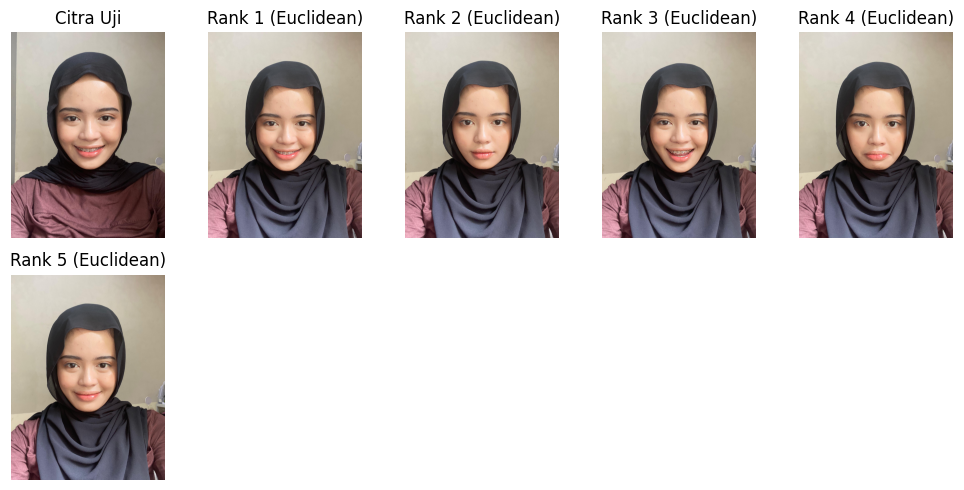


Menampilkan citra referensi terdekat (Cosine)...


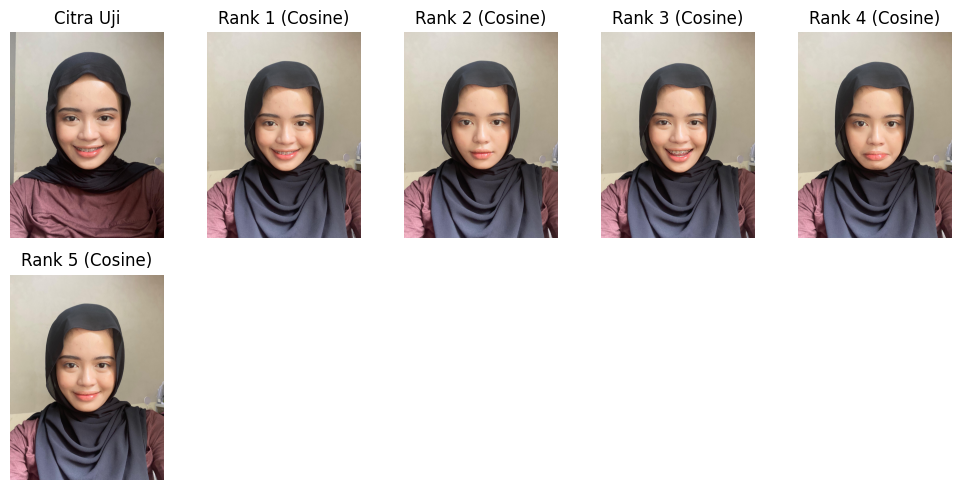

In [20]:
# Path referensi dan uji
path_referensi = "/content/drive/MyDrive/referensi"
path_uji = "/content/drive/MyDrive/uji2"

# Load Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Import library yang diperlukan
import os
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.feature import local_binary_pattern, hog
from skimage.transform import resize
from skimage.exposure import equalize_hist
from scipy.spatial.distance import cosine, euclidean
import numpy as np
import matplotlib.pyplot as plt

# Fungsi ekstraksi fitur LBP
def ekstraksi_lbp(image, n_points, radius):
    """
    Ekstraksi fitur Local Binary Pattern (LBP) dari citra.
    """
    lbp = local_binary_pattern(image, n_points, radius, method='uniform')
    n_bins = int(lbp.max() + 1)  # Jumlah bin histogram
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))
    return hist / sum(hist)  # Normalisasi histogram

# Fungsi ekstraksi fitur HOG
def ekstraksi_hog(image, pixels_per_cell=(8, 8), cells_per_block=(2, 2)):
    """
    Ekstraksi fitur Histogram of Oriented Gradients (HOG) dari citra.
    """
    fitur = hog(image,
                pixels_per_cell=pixels_per_cell,
                cells_per_block=cells_per_block,
                feature_vector=True)
    return fitur

# Parameter LBP dan HOG
N_POINTS = 24  # Tetangga
RADIUS = 3     # Radius
TARGET_SIZE = (128, 128)  # Ukuran normalisasi citra

# Membaca file referensi
file_referensi = os.listdir(path_referensi)
feat_referensi = []

print("Ekstraksi fitur dari dataset referensi...")
for file in file_referensi:
    img_path = os.path.join(path_referensi, file)
    img = imread(img_path)
    img_gray = rgb2gray(img)  # Konversi ke grayscale
    img_gray = resize(img_gray, TARGET_SIZE, anti_aliasing=True)  # Normalisasi ukuran
    img_gray = equalize_hist(img_gray)  # Normalisasi histogram

    # Ekstraksi fitur LBP dan HOG
    fitur_lbp = ekstraksi_lbp(img_gray, N_POINTS, RADIUS)
    fitur_hog = ekstraksi_hog(img_gray)

    # Gabungkan fitur LBP dan HOG
    fitur_kombinasi = np.hstack((fitur_lbp, fitur_hog))
    feat_referensi.append(fitur_kombinasi)

# Menampilkan sampel citra referensi
print("\nMenampilkan sampel citra referensi...")
plt.figure(figsize=(10, 5))
for i in range(min(4, len(file_referensi))):  # Maksimal 4 citra
    img_sample = imread(os.path.join(path_referensi, file_referensi[i]))
    plt.subplot(1, 4, i+1)
    plt.imshow(img_sample, cmap='gray')
    plt.title(f"Referensi {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Membaca file uji
file_uji = os.listdir(path_uji)

# Ekstraksi fitur citra uji
print("\nEkstraksi fitur dari dataset uji...")
ID_UJI = 0  # Index citra yang akan diuji
img_uji_path = os.path.join(path_uji, file_uji[ID_UJI])
img_uji = imread(img_uji_path)
img_uji_gray = rgb2gray(img_uji)
img_uji_gray = resize(img_uji_gray, TARGET_SIZE, anti_aliasing=True)  # Normalisasi ukuran
img_uji_gray = equalize_hist(img_uji_gray)  # Normalisasi histogram

# Ekstraksi fitur LBP dan HOG untuk citra uji
fitur_lbp_uji = ekstraksi_lbp(img_uji_gray, N_POINTS, RADIUS)
fitur_hog_uji = ekstraksi_hog(img_uji_gray)

# Gabungkan fitur LBP dan HOG untuk citra uji
feat_uji = np.hstack((fitur_lbp_uji, fitur_hog_uji))


# Menghitung jarak antara citra uji dan referensi dengan Euclidean dan Cosine Similarity
print("\nMenghitung jarak ke citra referensi...")
hasil = []
for idx, fitur_referensi in enumerate(feat_referensi):
    jarak_euclidean = euclidean(fitur_referensi, feat_uji)  # Jarak Euclidean
    jarak_cosine = cosine(fitur_referensi, feat_uji)  # Cosine Similarity
    hasil.append({"file_referensi": file_referensi[idx], "jarak_euclidean": jarak_euclidean, "jarak_cosine": jarak_cosine})

# Sort berdasarkan jarak Euclidean
hasil_sorted_euclidean = sorted(hasil, key=lambda x: x['jarak_euclidean'])
# Sort berdasarkan Cosine Similarity
hasil_sorted_cosine = sorted(hasil, key=lambda x: x['jarak_cosine'])

# Mengambil K-Nilai Terdekat
K_NEAREST = 5
top_k_euclidean = hasil_sorted_euclidean[:K_NEAREST]
top_k_cosine = hasil_sorted_cosine[:K_NEAREST]

# Menampilkan hasil terdekat untuk Euclidean
print("\nCitra referensi terdekat (Jarak Euclidean):")
for i, result in enumerate(top_k_euclidean):
    print(f"Rank {i+1}: {result['file_referensi']}, Jarak Euclidean: {result['jarak_euclidean']}")

# Menampilkan hasil terdekat untuk Cosine Similarity
print("\nCitra referensi terdekat (Cosine Similarity):")
for i, result in enumerate(top_k_cosine):
    print(f"Rank {i+1}: {result['file_referensi']}, Cosine Similarity: {result['jarak_cosine']}")

# Menampilkan citra referensi terdekat berdasarkan Euclidean
print("\nMenampilkan citra referensi terdekat (Euclidean)...")
plt.figure(figsize=(10, 5))

# Menampilkan citra uji
plt.subplot(2, K_NEAREST, 1)
plt.imshow(img_uji, cmap='gray')
plt.title("Citra Uji")
plt.axis('off')

# Menampilkan citra referensi terdekat berdasarkan Euclidean
for i, result in enumerate(top_k_euclidean):
    img_ref = imread(os.path.join(path_referensi, result['file_referensi']))
    plt.subplot(2, K_NEAREST, i+2)
    plt.imshow(img_ref, cmap='gray')
    plt.title(f"Rank {i+1} (Euclidean)")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Menampilkan citra referensi terdekat berdasarkan Cosine Similarity
print("\nMenampilkan citra referensi terdekat (Cosine)...")
plt.figure(figsize=(10, 5))

# Menampilkan citra uji
plt.subplot(2, K_NEAREST, 1)
plt.imshow(img_uji, cmap='gray')
plt.title("Citra Uji")
plt.axis('off')

# Menampilkan citra referensi terdekat berdasarkan Cosine Similarity
for i, result in enumerate(top_k_cosine):
    img_ref = imread(os.path.join(path_referensi, result['file_referensi']))
    plt.subplot(2, K_NEAREST, i+2)
    plt.imshow(img_ref, cmap='gray')
    plt.title(f"Rank {i+1} (Cosine)")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [21]:
# Menampilkan hasil jarak untuk semua foto referensi menggunakan dua metode
print("\nHasil jarak antara citra uji dan semua citra referensi:")

# Versi Euclidean
print("\nJarak dengan Euclidean:")
for idx, fitur_referensi in enumerate(feat_referensi):
    jarak_euclidean = euclidean(fitur_referensi, feat_uji)
    print(f"Referensi {file_referensi[idx]}: Jarak Euclidean = {jarak_euclidean:.4f}")

# Versi Cosine Similarity
print("\nJarak dengan Cosine Similarity:")
for idx, fitur_referensi in enumerate(feat_referensi):
    jarak_cosine = cosine(fitur_referensi, feat_uji)
    print(f"Referensi {file_referensi[idx]}: Cosine Similarity = {jarak_cosine:.4f}")



Hasil jarak antara citra uji dan semua citra referensi:

Jarak dengan Euclidean:
Referensi Zahra (6).jpg: Jarak Euclidean = 12.0033
Referensi Zahra (3).jpg: Jarak Euclidean = 12.0506
Referensi Zahra (2).jpg: Jarak Euclidean = 11.9036
Referensi rayka (4).jpg: Jarak Euclidean = 13.6681
Referensi rayka (5).jpg: Jarak Euclidean = 13.3937
Referensi Zahra (1).jpg: Jarak Euclidean = 12.0029
Referensi rayka (6).jpg: Jarak Euclidean = 13.4318
Referensi rayka (2).jpg: Jarak Euclidean = 13.6087
Referensi Zahra (4).jpg: Jarak Euclidean = 11.8242
Referensi Zahra (5).jpg: Jarak Euclidean = 11.8634
Referensi rayka (3).jpg: Jarak Euclidean = 13.6332
Referensi Rahayu (5).jpg: Jarak Euclidean = 12.9427
Referensi rayka (1).jpg: Jarak Euclidean = 13.7122
Referensi Raisa (5).jpg: Jarak Euclidean = 13.5229
Referensi Rahayu (1).jpg: Jarak Euclidean = 13.4631
Referensi Rahayu (3).jpg: Jarak Euclidean = 12.8245
Referensi Rahayu (4).jpg: Jarak Euclidean = 13.3016
Referensi Rahayu (2).jpg: Jarak Euclidean = 13.